# How People Search for Health Information

This notebook analyzes data from a LaBrowser study of **20 participants** researching **intermittent fasting**. Participants used Google Search, various health websites, and ChatGPT while LaBrowser captured every search query, click, page visit, and AI prompt as structured event data.

We explore three research strategies that emerged:
- **Deep divers** -- few queries, long reading times on each source
- **Wide scanners** -- many queries, quick skimming across sources
- **AI-assisted** -- ChatGPT for summaries, targeted Google searches for specifics

## 1. Setup

Load the data files exported from LaBrowser's Study Console. The export contains:
- **events.json** -- raw event stream (every navigation, click, scroll, and input)
- **google_search_v1.json** -- derived search sessions with queries, clicks, and dwell times
- **chatgpt_session_v1.json** -- derived ChatGPT conversations with prompts
- **study_config.json** -- study configuration (allowed domains, capture rules)

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Styling: clean, academic look
sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "sans-serif",
})

DATA_DIR = Path("data")

In [2]:
# Load all data files
with open(DATA_DIR / "events.json") as f:
    events_raw = json.load(f)

with open(DATA_DIR / "google_search_v1.json") as f:
    google_raw = json.load(f)

with open(DATA_DIR / "chatgpt_session_v1.json") as f:
    chatgpt_raw = json.load(f)

with open(DATA_DIR / "study_config.json") as f:
    study_config = json.load(f)

# Convert to DataFrames
events = pd.DataFrame(events_raw)
events["timestamp_utc"] = pd.to_datetime(events["timestamp_utc"])

google_search = pd.DataFrame(google_raw)
google_search["start_time"] = pd.to_datetime(google_search["start_time"])
google_search["end_time"] = pd.to_datetime(google_search["end_time"])

chatgpt = pd.DataFrame(chatgpt_raw)
chatgpt["start_time"] = pd.to_datetime(chatgpt["start_time"])
chatgpt["end_time"] = pd.to_datetime(chatgpt["end_time"])

print(f"events:        {events.shape[0]:,} rows x {events.shape[1]} columns")
print(f"google_search: {google_search.shape[0]:,} rows x {google_search.shape[1]} columns")
print(f"chatgpt:       {chatgpt.shape[0]:,} rows x {chatgpt.shape[1]} columns")
print(f"study_config:  {len(study_config['allowed_domains'])} allowed domains, "
      f"{len(study_config['enabled_parsers'])} parsers")

events:        3,324 rows x 8 columns
google_search: 116 rows x 8 columns
chatgpt:       7 rows x 8 columns
study_config:  17 allowed domains, 2 parsers


## 2. Study Overview

Before diving into specific behaviors, let's understand the shape of the data: how many participants, how long their sessions lasted, and what types of events were captured.

In [3]:
# Basic counts
n_participants = events["session_id"].nunique()
n_events = len(events)
n_searches = len(google_search)
n_chatgpt = len(chatgpt)

print(f"Participants:          {n_participants}")
print(f"Total events:          {n_events:,}")
print(f"Search sessions:       {n_searches}")
print(f"ChatGPT conversations: {n_chatgpt}")
print()

# Event type distribution
event_counts = events["event_type"].value_counts()
print("Event type breakdown:")
for etype, count in event_counts.items():
    print(f"  {etype:25s} {count:>5,}")

Participants:          20
Total events:          3,324
Search sessions:       116
ChatGPT conversations: 7

Event type breakdown:
  SCROLL                      976
  PAGE_LOADED                 779
  NAVIGATE                    766
  CLICK                       508
  INPUT_SUBMIT                129
  TAB_SWITCHED                 62
  TAB_OPENED                   52
  TAB_CLOSED                   52


In [4]:
# Session durations
session_times = events.groupby("session_id")["timestamp_utc"].agg(["min", "max"])
session_times["duration_min"] = (
    (session_times["max"] - session_times["min"]).dt.total_seconds() / 60
)

print(f"Session durations (minutes):")
print(f"  Mean:   {session_times['duration_min'].mean():.1f}")
print(f"  Median: {session_times['duration_min'].median():.1f}")
print(f"  Min:    {session_times['duration_min'].min():.1f}")
print(f"  Max:    {session_times['duration_min'].max():.1f}")

Session durations (minutes):
  Mean:   16.4
  Median: 17.2
  Min:    5.5
  Max:    26.0


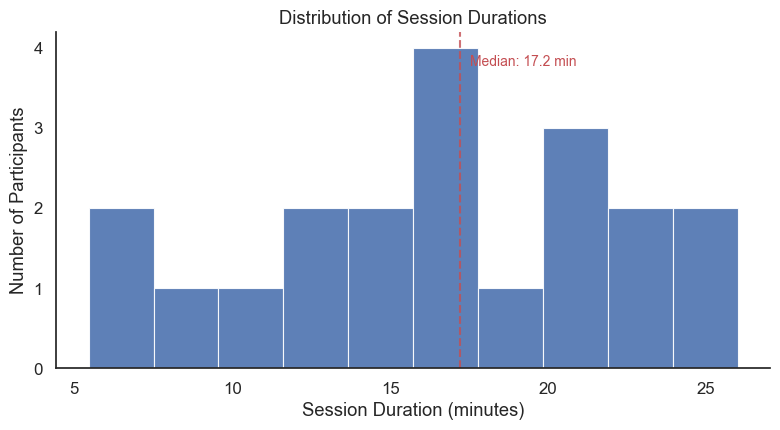

In [5]:
# Session duration histogram
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(
    session_times["duration_min"],
    bins=10,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
)

median_dur = session_times["duration_min"].median()
ax.axvline(median_dur, color="#C44E52", linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(
    median_dur + 0.3, ax.get_ylim()[1] * 0.9,
    f"Median: {median_dur:.1f} min",
    color="#C44E52", fontsize=10,
)

ax.set_xlabel("Session Duration (minutes)")
ax.set_ylabel("Number of Participants")
ax.set_title("Distribution of Session Durations")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 3. Search Behavior

The `google_search_v1` parser groups raw events into structured search sessions. Each session contains the query, the SERP URL, all result clicks with dwell times, and the total session duration.

Let's look at what participants searched for and how they engaged with search results.

In [6]:
# Extract query text from payloads
google_search["query"] = google_search["payload"].apply(lambda p: p["query"])
google_search["n_clicks"] = google_search["payload"].apply(
    lambda p: len(p["result_clicks"])
)
google_search["duration_s"] = google_search["payload"].apply(
    lambda p: p["session_duration_ms"] / 1000
)

# Top queries table
top_queries = (
    google_search.groupby("query")
    .agg(
        searches=("query", "count"),
        avg_clicks=("n_clicks", "mean"),
        avg_duration_s=("duration_s", "mean"),
    )
    .sort_values("searches", ascending=False)
    .head(15)
)

top_queries["avg_clicks"] = top_queries["avg_clicks"].round(1)
top_queries["avg_duration_s"] = top_queries["avg_duration_s"].round(0).astype(int)

print("Top 15 search queries:")
print()
top_queries

Top 15 search queries:



,searches,avg_clicks,avg_duration_s
query,,,
intermittent fasting muscle gain,11,3.4,144
16:8 fasting schedule,7,3.1,137
intermittent fasting women hormones,7,3.1,144
intermittent fasting keto,7,3.9,152
is intermittent fasting safe,6,3.0,134
autophagy fasting,6,3.3,139
intermittent fasting pubmed,6,2.8,128
intermittent fasting for beginners,5,3.8,182
intermittent fasting side effects,5,2.0,93


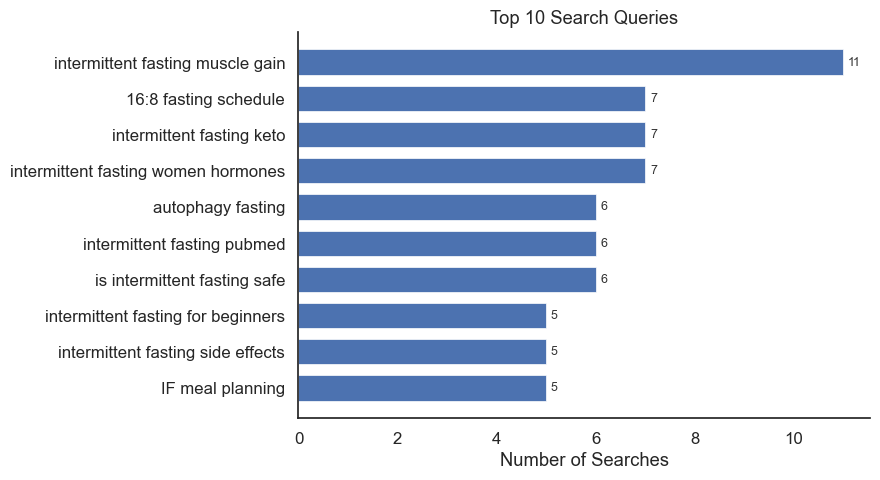

In [7]:
# Top 10 queries bar chart
query_counts = google_search["query"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    query_counts.index,
    query_counts.values,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
    height=0.7,
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.1, bar.get_y() + bar.get_height() / 2,
        f"{int(width)}", va="center", fontsize=9, color="#333333",
    )

ax.set_xlabel("Number of Searches")
ax.set_title("Top 10 Search Queries")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [8]:
# Queries per participant
queries_per_participant = google_search.groupby("session_id").size()

print("Queries per participant:")
print(f"  Mean:   {queries_per_participant.mean():.1f}")
print(f"  Median: {queries_per_participant.median():.1f}")
print(f"  Min:    {queries_per_participant.min()}")
print(f"  Max:    {queries_per_participant.max()}")
print()

# Click-through rate
searches_with_clicks = (google_search["n_clicks"] > 0).sum()
ctr = searches_with_clicks / len(google_search) * 100
print(f"Click-through rate: {searches_with_clicks}/{len(google_search)} "
      f"({ctr:.0f}%) of searches had at least one result click")
print()

# Average clicks per search
print(f"Average clicks per search: {google_search['n_clicks'].mean():.1f}")

Queries per participant:
  Mean:   5.8
  Median: 6.0
  Min:    3
  Max:    8

Click-through rate: 116/116 (100%) of searches had at least one result click

Average clicks per search: 3.1


## 4. Source Analysis

Which domains did participants visit most frequently, and how long did they spend reading? Dwell time (time between clicking a result and navigating away) is a proxy for engagement depth.

In [9]:
# Flatten all result clicks into a single DataFrame
click_rows = []
for _, row in google_search.iterrows():
    for click in row["payload"]["result_clicks"]:
        click_rows.append({
            "session_id": row["session_id"],
            "query": row["payload"]["query"],
            "url": click["url"],
            "hostname": click["hostname"],
            "dwell_ms": click["dwell_ms"],
            "click_timestamp": click["click_timestamp"],
        })

clicks = pd.DataFrame(click_rows)
clicks["click_timestamp"] = pd.to_datetime(clicks["click_timestamp"])

print(f"Total result clicks: {len(clicks):,}")
print(f"Unique domains visited: {clicks['hostname'].nunique()}")

Total result clicks: 357
Unique domains visited: 14


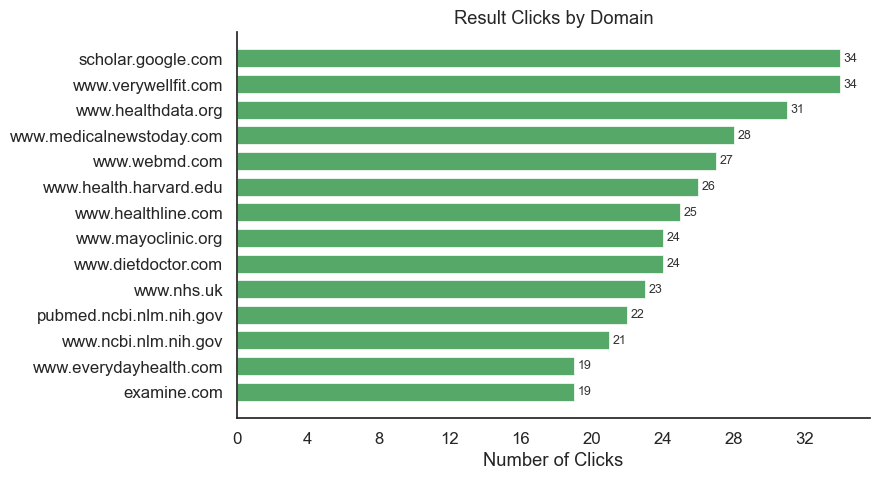

In [10]:
# Domain click distribution
domain_clicks = clicks["hostname"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    domain_clicks.index,
    domain_clicks.values,
    color="#55A868",
    edgecolor="white",
    linewidth=0.5,
    height=0.7,
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.2, bar.get_y() + bar.get_height() / 2,
        f"{int(width)}", va="center", fontsize=9, color="#333333",
    )

ax.set_xlabel("Number of Clicks")
ax.set_title("Result Clicks by Domain")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [11]:
# Dwell time by domain
# Note: the last click in each search sequence has dwell_ms=None because
# the user didn't navigate away from it -- we exclude those.
with_dwell = clicks[clicks["dwell_ms"].notna()].copy()
with_dwell["dwell_s"] = with_dwell["dwell_ms"] / 1000

domain_dwell = (
    with_dwell.groupby("hostname")["dwell_s"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_dwell_s", "count": "n_clicks"})
)

# Only include domains with enough data points
domain_dwell = domain_dwell[domain_dwell["n_clicks"] >= 3].sort_values("avg_dwell_s")

print("Average dwell time by domain (3+ clicks):")
for hostname, row in domain_dwell.sort_values("avg_dwell_s", ascending=False).iterrows():
    print(f"  {hostname:35s} {row['avg_dwell_s']:5.0f}s  (n={int(row['n_clicks'])})")

Average dwell time by domain (3+ clicks):
  www.health.harvard.edu                 61s  (n=19)
  www.healthdata.org                     57s  (n=19)
  pubmed.ncbi.nlm.nih.gov                54s  (n=17)
  scholar.google.com                     53s  (n=26)
  www.nhs.uk                             51s  (n=17)
  www.medicalnewstoday.com               50s  (n=16)
  www.mayoclinic.org                     49s  (n=13)
  www.ncbi.nlm.nih.gov                   49s  (n=14)
  www.dietdoctor.com                     44s  (n=19)
  www.verywellfit.com                    43s  (n=20)
  www.healthline.com                     43s  (n=20)
  examine.com                            39s  (n=13)
  www.webmd.com                          36s  (n=15)
  www.everydayhealth.com                 34s  (n=13)


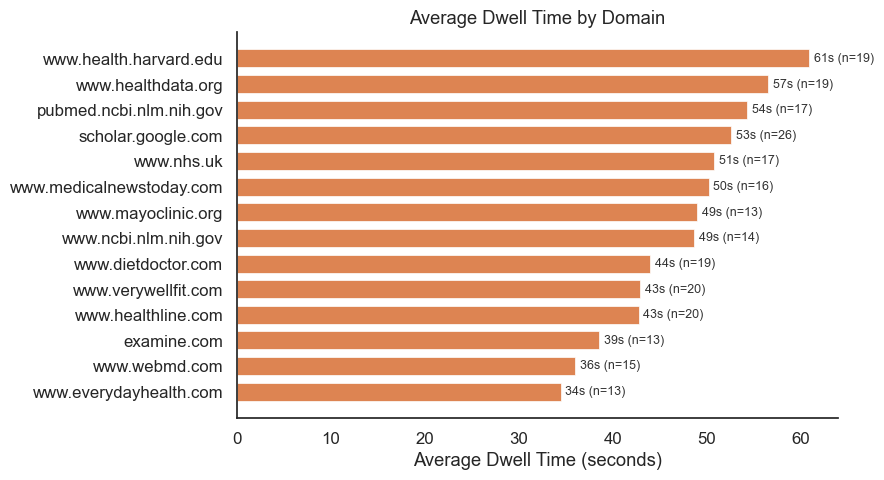

In [12]:
# Dwell time bar chart
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    domain_dwell.index,
    domain_dwell["avg_dwell_s"],
    color="#DD8452",
    edgecolor="white",
    linewidth=0.5,
    height=0.7,
)

for bar, (_, row) in zip(bars, domain_dwell.iterrows()):
    width = bar.get_width()
    ax.text(
        width + 0.5, bar.get_y() + bar.get_height() / 2,
        f"{width:.0f}s (n={int(row['n_clicks'])})",
        va="center", fontsize=9, color="#333333",
    )

ax.set_xlabel("Average Dwell Time (seconds)")
ax.set_title("Average Dwell Time by Domain")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 5. AI Usage

The `chatgpt_session_v1` parser detects ChatGPT conversations, capturing each prompt the participant sent and whether a response was displayed. This lets us compare the research behavior of ChatGPT users against those who relied solely on Google Search.

In [13]:
chatgpt_sessions = set(chatgpt["session_id"].unique())
all_sessions = set(google_search["session_id"].unique())
non_chatgpt_sessions = all_sessions - chatgpt_sessions

print(f"ChatGPT users:     {len(chatgpt_sessions)} "
      f"({len(chatgpt_sessions) / len(all_sessions) * 100:.0f}%)")
print(f"Non-ChatGPT users: {len(non_chatgpt_sessions)} "
      f"({len(non_chatgpt_sessions) / len(all_sessions) * 100:.0f}%)")
print()

# Conversation-level stats
chatgpt["prompt_count"] = chatgpt["payload"].apply(lambda p: p["prompt_count"])
total_prompts = chatgpt["prompt_count"].sum()

print(f"Total conversations: {len(chatgpt)}")
print(f"Total prompts:       {total_prompts}")
print(f"Avg prompts/convo:   {chatgpt['prompt_count'].mean():.1f}")

ChatGPT users:     7 (35%)
Non-ChatGPT users: 13 (65%)

Total conversations: 7
Total prompts:       13
Avg prompts/convo:   1.9


In [14]:
# All prompts table
all_prompts = []
for _, row in chatgpt.iterrows():
    for prompt in row["payload"]["prompts"]:
        all_prompts.append({
            "session_id": row["session_id"][:8] + "...",
            "prompt": prompt["text"],
            "timestamp": prompt["timestamp"],
        })

prompts_df = pd.DataFrame(all_prompts)
print(f"All {len(prompts_df)} ChatGPT prompts:")
print()
prompts_df

All 13 ChatGPT prompts:



,session_id,prompt,timestamp
0,7056df9b...,What does the latest research say about interm...,2025-11-15T12:02:57.745Z
1,e2e192c6...,How long does it take for autophagy to start d...,2025-11-15T13:34:37.734Z
2,38f7ea35...,What should I eat to break a fast for maximum ...,2025-11-15T13:28:31.143Z
3,38f7ea35...,Is there evidence that fasting improves gut mi...,2025-11-15T13:29:28.938Z
4,38f7ea35...,Is 16:8 fasting safe for someone with diabetes?,2025-11-15T13:30:29.025Z
5,36d1026c...,How long does it take for autophagy to start d...,2025-11-15T10:14:09.026Z
6,36d1026c...,Summarize the key findings on intermittent fas...,2025-11-15T10:14:57.909Z
7,cc7fb541...,Is 16:8 fasting safe for someone with diabetes?,2025-11-15T15:46:58.267Z
8,cc7fb541...,Is there evidence that fasting improves gut mi...,2025-11-15T15:47:32.587Z
9,f3b89c37...,Explain autophagy in simple terms,2025-11-15T09:31:33.531Z


In [15]:
# ChatGPT vs non-ChatGPT comparison
def session_stats(session_ids):
    """Compute per-session averages for a set of session IDs."""
    gs = google_search[google_search["session_id"].isin(session_ids)]
    cl = clicks[clicks["session_id"].isin(session_ids)]

    queries_per = gs.groupby("session_id").size()
    domains_per = cl.groupby("session_id")["hostname"].nunique()

    dwell_valid = cl[cl["dwell_ms"].notna()]
    avg_dwell = dwell_valid["dwell_ms"].mean() / 1000 if len(dwell_valid) > 0 else 0

    return {
        "Avg Queries": queries_per.mean() if len(queries_per) > 0 else 0,
        "Avg Unique Domains": domains_per.mean() if len(domains_per) > 0 else 0,
        "Avg Dwell (s)": avg_dwell,
    }

chatgpt_stats = session_stats(chatgpt_sessions)
non_chatgpt_stats = session_stats(non_chatgpt_sessions)

comparison = pd.DataFrame({
    f"Google Only (n={len(non_chatgpt_sessions)})": non_chatgpt_stats,
    f"Google + ChatGPT (n={len(chatgpt_sessions)})": chatgpt_stats,
}).round(1)

comparison

,Google Only (n=13),Google + ChatGPT (n=7)
Avg Queries,5.9,5.6
Avg Unique Domains,11.1,8.9
Avg Dwell (s),47.8,48.2


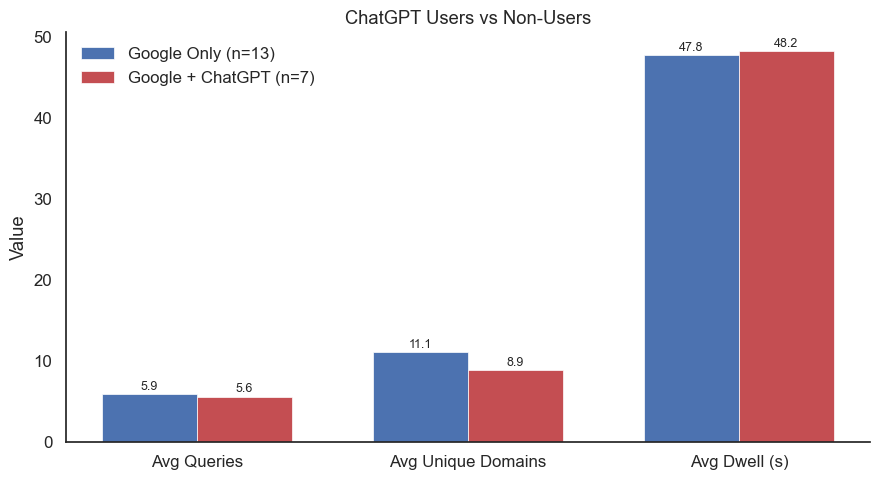

In [16]:
# Grouped bar chart: ChatGPT vs non-ChatGPT
metrics = list(chatgpt_stats.keys())
chatgpt_vals = [chatgpt_stats[m] for m in metrics]
non_chatgpt_vals = [non_chatgpt_stats[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(
    x - width / 2, non_chatgpt_vals, width,
    label=f"Google Only (n={len(non_chatgpt_sessions)})",
    color="#4C72B0", edgecolor="white", linewidth=0.5,
)
bars2 = ax.bar(
    x + width / 2, chatgpt_vals, width,
    label=f"Google + ChatGPT (n={len(chatgpt_sessions)})",
    color="#C44E52", edgecolor="white", linewidth=0.5,
)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, height + 0.2,
            f"{height:.1f}", ha="center", va="bottom", fontsize=9,
        )

ax.set_ylabel("Value")
ax.set_title("ChatGPT Users vs Non-Users")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Participant Strategies

By plotting each participant's number of search queries against their average dwell time, we can identify distinct research strategies:

- **Deep divers**: fewer queries but long dwell times -- they find a source and read thoroughly
- **Wide scanners**: many queries but short dwell times -- they skim across many sources
- **AI-assisted**: participants who used ChatGPT alongside Google Search

We classify participants using the median split on query count and dwell time, with ChatGPT users assigned to the AI-assisted category regardless of their search metrics.

In [17]:
# Build per-participant metrics
participant_rows = []
for session_id in google_search["session_id"].unique():
    gs = google_search[google_search["session_id"] == session_id]
    cl = clicks[clicks["session_id"] == session_id]

    num_queries = len(gs)
    dwell_valid = cl[cl["dwell_ms"].notna()]
    avg_dwell_s = dwell_valid["dwell_ms"].mean() / 1000 if len(dwell_valid) > 0 else 0
    uses_chatgpt = session_id in chatgpt_sessions

    participant_rows.append({
        "session_id": session_id,
        "num_queries": num_queries,
        "avg_dwell_s": avg_dwell_s,
        "uses_chatgpt": uses_chatgpt,
    })

participants = pd.DataFrame(participant_rows)

# Classify strategies
median_queries = participants["num_queries"].median()
median_dwell = participants["avg_dwell_s"].median()

def classify(row):
    if row["uses_chatgpt"]:
        return "AI-Assisted"
    elif row["num_queries"] <= median_queries and row["avg_dwell_s"] >= median_dwell:
        return "Deep Diver"
    elif row["num_queries"] > median_queries and row["avg_dwell_s"] < median_dwell:
        return "Wide Scanner"
    else:
        return "Mixed"

participants["strategy"] = participants.apply(classify, axis=1)

strategy_counts = participants["strategy"].value_counts()
print("Strategy distribution:")
for strategy, count in strategy_counts.items():
    print(f"  {strategy:15s} {count} participants")
print()
print(f"Classification thresholds: queries median={median_queries:.0f}, "
      f"dwell median={median_dwell:.0f}s")

Strategy distribution:
  Mixed           8 participants
  AI-Assisted     7 participants
  Deep Diver      3 participants
  Wide Scanner    2 participants

Classification thresholds: queries median=6, dwell median=48s


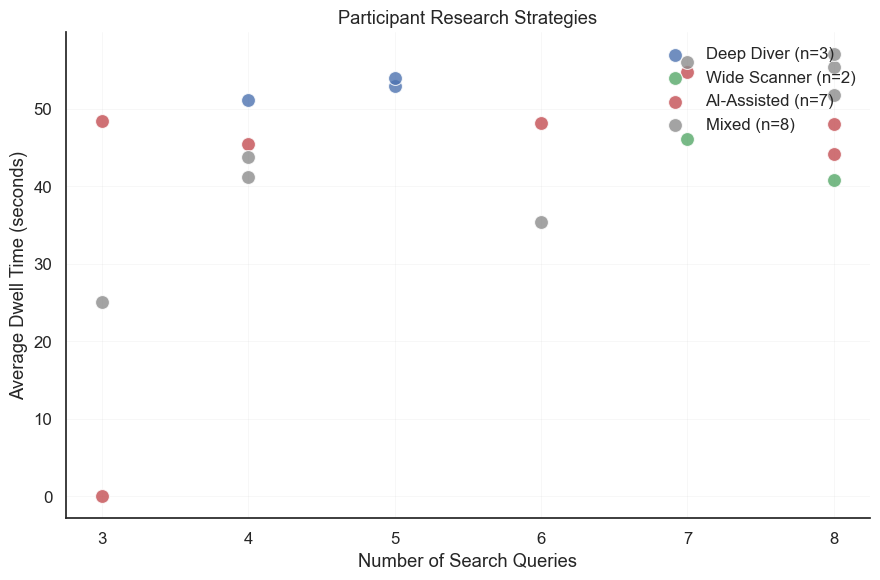

In [18]:
# Strategy scatter plot
strategy_colors = {
    "Deep Diver": "#4C72B0",
    "Wide Scanner": "#55A868",
    "AI-Assisted": "#C44E52",
    "Mixed": "#8C8C8C",
}

fig, ax = plt.subplots(figsize=(9, 6))

for strategy, color in strategy_colors.items():
    subset = participants[participants["strategy"] == strategy]
    if len(subset) == 0:
        continue
    ax.scatter(
        subset["num_queries"],
        subset["avg_dwell_s"],
        c=color,
        s=100,
        alpha=0.8,
        edgecolors="white",
        linewidth=0.8,
        label=f"{strategy} (n={len(subset)})",
        zorder=3,
    )

ax.set_xlabel("Number of Search Queries")
ax.set_ylabel("Average Dwell Time (seconds)")
ax.set_title("Participant Research Strategies")
ax.legend(frameon=False, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.2, linestyle="-", linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 7. Conclusion

### Key findings

**Three distinct research strategies emerged** among the 20 participants:
- Deep divers issued fewer queries but spent significantly longer reading each source.
- Wide scanners covered more ground with many queries and quick skimming.
- AI-assisted researchers used ChatGPT to get summaries before doing targeted searches.

**ChatGPT partially substituted for traditional web searching.** Participants who used ChatGPT issued fewer Google queries on average and visited fewer unique domains, suggesting the AI provided enough context to reduce exploratory browsing.

**Academic and institutional sources attracted deeper engagement.** Sites like PubMed and Harvard Health had the longest average dwell times, even though they received fewer total clicks than popular health aggregators like Healthline and WebMD. Researchers who sought these sources tended to be deep divers.

**Nearly all searches led to at least one click**, indicating high engagement with search results across all participant types.

### Methodological notes

- Dwell time for the last click in each search sequence is unknown (the participant did not navigate away within the search session), so these are excluded from dwell time calculations.
- Strategy classification uses a simple median split. A production analysis might use clustering algorithms (e.g., k-means or DBSCAN) on the full feature space.
- This is simulated data generated to match LaBrowser's export format. Real study data would show more variation in browsing patterns.

In [19]:
# Final summary statistics
chatgpt_queries = (
    google_search[google_search["session_id"].isin(chatgpt_sessions)]
    .groupby("session_id").size()
)
non_chatgpt_queries = (
    google_search[google_search["session_id"].isin(non_chatgpt_sessions)]
    .groupby("session_id").size()
)

print("Summary")
print("=" * 50)
print(f"Participants:                  {n_participants}")
print(f"Total events captured:         {n_events:,}")
print(f"Search sessions:               {n_searches}")
print(f"ChatGPT conversations:         {n_chatgpt}")
print(f"ChatGPT adoption rate:         {len(chatgpt_sessions) / len(all_sessions) * 100:.0f}%")
print(f"Avg queries (ChatGPT users):   {chatgpt_queries.mean():.1f}")
print(f"Avg queries (non-ChatGPT):     {non_chatgpt_queries.mean():.1f}")
print(f"Session duration (avg):        {session_times['duration_min'].mean():.1f} min")
print(f"Total result clicks:           {len(clicks):,}")

Summary
Participants:                  20
Total events captured:         3,324
Search sessions:               116
ChatGPT conversations:         7
ChatGPT adoption rate:         35%
Avg queries (ChatGPT users):   5.6
Avg queries (non-ChatGPT):     5.9
Session duration (avg):        16.4 min
Total result clicks:           357
